# Macchine a vettori di supporto

*Support Vector Machines* (SVM)

![vettori di supporto](17_01.png)

**obiettivo**: si vuole trovare il miglior piano separatore, ossia l'iperpiano che massimizza il margine, ossia la distanza dal margine
**a che serve**? tende a stare un po piu largo. Se l'iperpiano e' attaccato ad un punto etichettato come blu, tutti quelli a destra saranno arancioni, vorrei piuttosto allontanarmi dal punti blu in modo da avere la possibilita di etichettarne qualcuno come blu li dove ne avrei etichettati arancioni.
**quando funziona**? se l'istanza e' separabile

**massimizzare il margine**: vuol dire rendere il modello piu robusto in fase di test.

Nel contesto della classificazione binaria, sia assuma per il momento che le due classi con etichette $-1$ e $+1$, siano separabili linearmente dall'iperpiano

$$
H: w\cdot x + w_0 = 0.
$$

Per alcuni esempi della classe $+1$ si avrà

$$H^+: w\cdot x^+ +w_0 = +1$$

e per alcuni della classe $-1$, 

$$H^-: w\cdot x^- + w_0 = -1$$

**vettori di supporto**: Gli esempi $x^+$ e $x^-$ sono detti *vettori di supporto*. 

**obiettivo**: si vuole massimizzare la distanza tra gli iperpiani paralleli $H^+$ e $H^-$, ovvero *massimizzare il margine* in modo da abbassare l'errore di *generalizzazione*.

**massimizzare vuol dire minimizzare**: l'errore di generalizzazione

**distanza tra $H^+$ e $H^-$**: la possiamo vedere come la distanza di $x^+$ da $H$ più la distanza di $x^-$ da $H$ (nota: qui parliamo di distanza con segno, ecco perche' compare il -)

$$
d = \frac{w\cdot x^+}{\| w \|} - \frac{w\cdot x^-}{\| w \|}
$$

Ricordiamo che la distanza $(w\cdot x)/\| w \|$ è con segno, ovvero negativa, se il punto è nell'iperspazio negativo. Usando le considerazioni su $H^+$ e $H^-$:
* $H^+: w\cdot x^+ +w_0 = 1 \to 1-w_0 = w\cdot x^+$
* similmente per $H^-$

$$
d = \frac{1-w_0}{\| w \|} - \frac{-1-w_0}{\| w \|} = \frac{2}{\|w\|}
$$


**quadrato e reciproco**: l'obiettivo è massimizzare $2/\| w\| $. 
* Poiché $\| w\|$ contiene una radice conviene ottimizzare il quadrato 
* si passa al reciproco, minimizzandolo. 

Quindi la funzione obiettivo diventa:
$$
\frac{1}{2}\|w\|^2
$$

**vincoli**: che gli esempi siano classificati correttamente ovvero, per ogni esempio $x^{(i)}$ con $i=1,\ldots,n$,

$$
y_i(w\cdot x^{(i)}+w_0) \geq 1.
$$
* ogni volta che sbaglio l'etichetta succede che viene tutto $< 1$

## Casi non separabili linearmente

In questi casi i vincoli precenti non possono essere soddisfatti e il problema non ammette soluzioni.

**slack**:'si ammorbidiscono' i vincoli introducento $n$ variabili positive dette *slack* nel seguente modo:

$$
w\cdot x^{(i)}+w_0 \geq 1 - \xi^{(i)} \quad \text{se $y^{(i)} = 1$}
$$

$$
w\cdot x^{(i)}+w_0 \leq -1 + \xi^{(i)} \quad \text{se $y^{(i)} = -1$}
$$

$$
\xi^{(i)} \geq 0
$$

**come funzionano**? 
* Più le $\xi$ sono vicine a $0$ e più il vincolo è forte 
* più sono grandi (ricorda che sono $\geq 0$) più il margine è ammorbidito. 

Quindi la funzione obiettivo diventa
$$
\frac{1}{2}\|w\|^2 + C\sum_{i=1}^{n} \xi^{(i)}
$$

**a che serve $C$**? controlla quanto penalizzare le classificazioni errate. Con valori grandi si penalizzano maggiormente.

Questo problema può essere risolto con tecniche di programmazione quadratica ma anche con discesa del gradiente ma allo scopo dobbiamo eliminare i vincoli.

## Hinge loss

**funzioni cerniera**: elimino i vincoli nella precedente formulazione attraverso la sostituzione delle variabili $\xi^{(i)}$ con delle funzioni 'cerniera' che
* valgono $0$ in caso di classificazione **corretta** 
* crescono linearmente man mano che **aumenta l'errore**.

$$
\xi^{(i)} = \max\left(0, 1 - y^{(i)}(w\cdot x^{(i)} + w_0) \right)
$$

Nel caso di classificazione corretta $y^{(i)}(w\cdot x^{(i)} + w_0) \geq 1$ quindi $\xi^{(i)}$ vale $0$, altrimenti diventa via via più grande man mano che $y^{(i)}(w\cdot x^{(i)} + w_0)$ si allontana da $1$ verso sinistra. Nell'immagine un plot di una ipotetica funzione hinge.

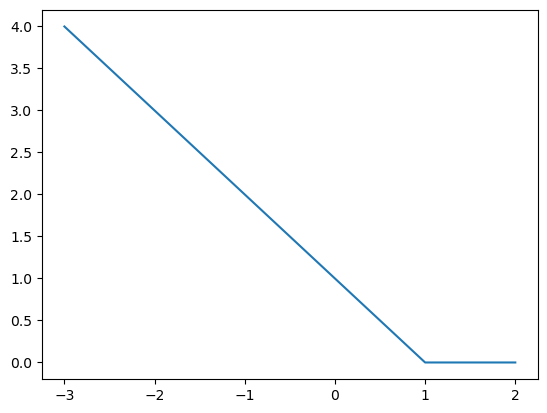

In [322]:
import numpy as np
import matplotlib.pyplot as plt

def xi(z):
    return max(0, 1-z)

z_val = np.arange(-3, 3, 1)
plt.plot(z_val, [xi(z) for z in z_val])

Pertanto la funzione obiettivo diventa

$$
J(w) = \frac{1}{2}\|w\|^2 + C\sum_{i=1}^{n} \max\left(0, 1 - y^{(i)}(w\cdot x^{(i)} + w_0) \right)
$$

Si osservi che ora i vincoli non sono più necessari in quanto sostituendo alle $\xi^{(i)}$ le funzioni hinge questi risultano sempre soddisfatti.

Abbiamo incorporato il problema di minimizzazione dei vincoli, nella discesa del gradiente!

## Discesa del gradiente

Partiamo con il calcolare le derivate parziali di $J(w)$, ma non possiamo farlo: **la funzione non e' continua**

$$
\frac{d}{d w_j} J(w) = w_j + C \frac{d}{d w_j} \sum_{i=1}^n \max\left(0, 1 - y^{(i)}(w\cdot x^{(i)} + w_0) \right)
$$

**La derivata della sommatoria non può essere generalizzata perché dipende dal segno di**

$$
1-y^{(i)}( w\cdot x^{(i)} + w_0 ).
$$


Se $1-y^{(i)}( w\cdot x^{(i)} + w_0 ) < 0$ (esempio classificato correttamente)

$$
\frac{d}{d w_j} \max\left(0, 1 - y^{(i)}(w\cdot x^{(i)} + w_0) \right) = 0.
$$

Se $1-y^{(i)}( w\cdot x^{(i)} + w_0 ) \geq 0$

$$
\frac{d}{d w_j} \max\left(0, 1 - y^{(i)}(w\cdot x^{(i)} + w_0) \right) = -y^{(i)}x_j^{(i)}.
$$

Questo ci fornisce un metodo su come aggiornare il pesi $w$: usando un approccio stocastico, per ogni nuovo esempio $x^{(i)}$

$$
w  \leftarrow \left\{
\begin{array}{lcl}
w - \eta w & & \text{se $y^{(i)}( w\cdot x^{(i)} + w_0 ) > 1$}\\
w - \eta \left(w  - C y^{(i)} x^{(i)} \right) & & \text{altrimenti}
\end{array}
\right.
$$

In [323]:
import os
import numpy as np
import pandas as pd


import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

from time import time


def plot_decision_regions(X, y, classifier, resolution=0.02):

    # setup marker generator and color map
    markers = ('s', '*', 'o', '^', 'v', '*')
    colors = ('red', 'blue', 'lightgreen', 'gray', 'cyan')
    cmap = ListedColormap(colors[:len(np.unique(y))])

    # plot the decision surface
    x1_min, x1_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    x2_min, x2_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx1, xx2 = np.meshgrid(np.arange(x1_min, x1_max, resolution),
                           np.arange(x2_min, x2_max, resolution))
    Z = classifier.predict(np.array([xx1.ravel(), xx2.ravel()]).T)
    Z = Z.reshape(xx1.shape)
    plt.contourf(xx1, xx2, Z, alpha=0.3, cmap=cmap)
    plt.xlim(xx1.min(), xx1.max())
    plt.ylim(xx2.min(), xx2.max())

    # plot class examples
    for idx, cl in enumerate(np.unique(y)):
        plt.scatter(x=X[y == cl, 0], 
                    y=X[y == cl, 1],
                    alpha=0.8, 
                    c=colors[idx],
                    marker=markers[idx], 
                    label=cl, 
                    edgecolor='black')

In [324]:
class SVM(object):
    """Support Vector Machine (SVM) classifier using gradient descent."""

    
    def __init__(self, eta=0.01, n_iter=1000, C=1.0, random_state=1, tol=1e-4, verbose=True):
        self.eta = eta  # Learning rate
        self.n_iter = n_iter  # Number of iterations
        self.C = C  # Regularization parameter
        self.random_state = random_state
        # tolleranza: interrompe la computazione prima delle epoche fissate
        self.tol = tol  # Tolerance for early stopping
        self.verbose = verbose  # Print iterations
    
    def fit(self, X, y):
        rgen = np.random.RandomState(self.random_state)
        # inizializza i pesi in un intervallo molto vicino allo 0
        self.w_ = rgen.normal(loc=0.0, scale=0.01, size=1 + X.shape[1])
        self.last_cost = None
        
        for count in range(self.n_iter):
            cost = 0
            for xi, yi in zip(X, y):
                # questa e' la formula del margine
                margin = yi * (np.dot(xi, self.w_[1:]) + self.w_[0])
                
                # aggiorna in base alle due formule viste prima
                if margin >= 1: # vuol dire che ho classificato bene ma potrebbe esserci un margine enorme.
                    self.w_ -= self.eta * self.w_ 
                else:
                    # se ho sbagliato aggiorno cosi
                    self.w_[1:] -= self.eta * (self.w_[1:] - self.C * yi * xi)
                    # il termine noto ha la variabile che vale sempre 1 !  
                    self.w_[0] -= self.eta * (-self.C * yi)
                
                # definizione del costo!
                cost += max(0, 1 - margin)  
            
            # controlla se l'aggiornamento cambia di poco il margine
            # in base alla tol
            if self.last_cost is not None and abs(cost - self.last_cost) < self.tol:
                if self.verbose:
                    print(f'Uscita anticipata dopo {count} iterazioni')
                break
            self.last_cost = cost
        
        return self
    
    def predict(self, X):
        return np.where(np.dot(X, self.w_[1:]) + self.w_[0] >= 0, 1, -1)


In [325]:
s = os.path.join('dataset', '01-02-iris.csv')
df = pd.read_csv(s,
                 header=None,
                 encoding='utf-8')

## Esempi

### Separabile

In [326]:
# [0:50] iris-setosa
# [50:100] iris-versicolor
# [100:150] iris-virginica
y = df.iloc[:100, 4].values
y = np.where(y == 'Iris-versicolor', 1, -1)

# extract sepal length and petal length
X = df.iloc[:100, [0, 2]].values

X_std = (X-X.mean(0))/X.std(0)

Uscita anticipata dopo 8 iterazioni
Accuratezza: 1.0 
	Secondi: 0.029279708862304688


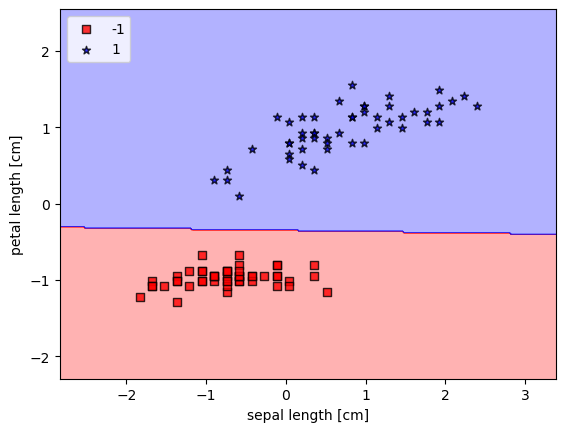

In [327]:
start_time = time()
svm = SVM(eta=0.001, C=1000, n_iter=1000, tol=0.01).fit(X_std, y)
end_time = time()
accuracy = np.mean(svm.predict(X_std) == y)
print('Accuratezza:', accuracy, '\n\tSecondi:', end_time-start_time)

plot_decision_regions(X_std, y, classifier=svm)

plt.xlabel('sepal length [cm]')
plt.ylabel('petal length [cm]')
plt.legend(loc='upper left')

### Non separabile

In [328]:
# [0:50] iris-setosa
# [50:100] iris-versicolor
# [100:150] iris-virginica
y = df.iloc[50:, 4].values
y = np.where(y == 'Iris-versicolor', 1, -1)

# extract sepal length and petal length
X = df.iloc[50:, [0, 2]].values

X_std = (X-X.mean(0))/X.std(0)

Uscita anticipata dopo 34 iterazioni
Accuratezza: 0.92 
	Secondi: 0.04580950736999512


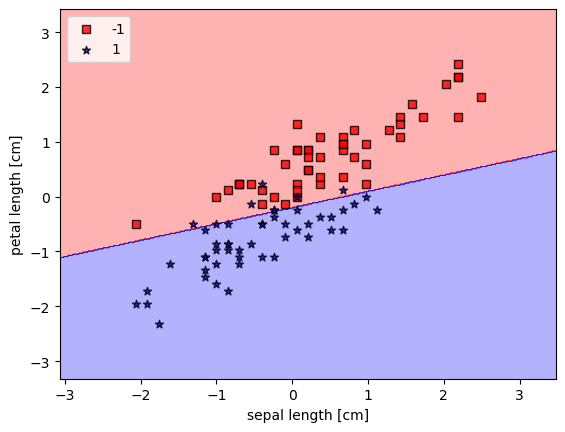

In [329]:
start_time = time()
svm = SVM(eta=0.001, C=50, n_iter=1000, tol=0.01).fit(X_std, y)
end_time = time()
accuracy = np.mean(svm.predict(X_std) == y)
print('Accuratezza:', accuracy, '\n\tSecondi:', end_time-start_time)

plot_decision_regions(X_std, y, classifier=svm)

plt.xlabel('sepal length [cm]')
plt.ylabel('petal length [cm]')
plt.legend(loc='upper left')

Testare altri valori dell'iper parametro `C`.

`OSS`: 
* se `C` elevato e le istanze sono separabili, allora aumento l'importanza dello spacing dell'iperpiano rispetto alle due classi.
* se `C=0`: allora massimizzo la distanza dell'iperpiano da tutti i punti, non ho vincoli.


Nel caso non separabile: usando `C=50` invece di `C=100` migliora l'accuracy.

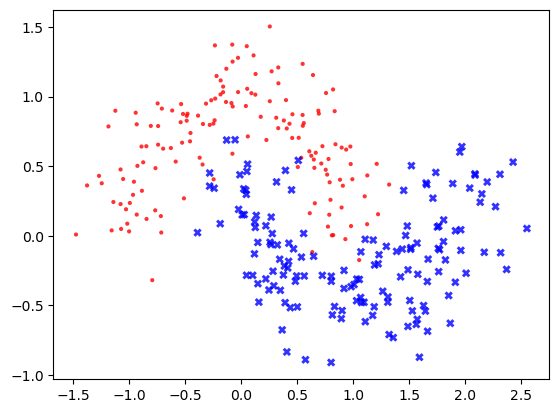

In [330]:
from sklearn.datasets import make_moons

X, y = make_moons(n_samples=300, noise=0.2, random_state=42)

markers=['.', 'X']
colors = ['r', 'b']

for idx, cl in enumerate(np.unique(y)):
        plt.scatter(x=X[y == cl, 0], 
                    y=X[y == cl, 1],
                    alpha=0.8, 
                    c=colors[idx],
                    marker=markers[idx], 
                    label=cl, 
                    edgecolor='none')

In [331]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=1
)

In [332]:
from sklearn.svm import SVC

linear_svm = SVC(kernel='linear')
linear_svm.fit(X_train, y_train)

y_pred_linear = linear_svm.predict(X_test)
print("Accuracy SVM lineare:", np.mean(y_test == y_pred_linear))


Accuracy SVM lineare: 0.8666666666666667


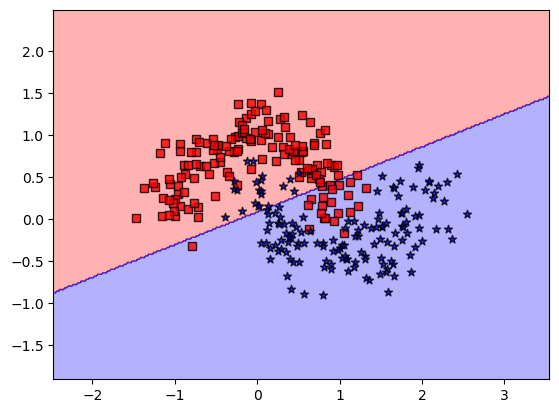

In [333]:
plot_decision_regions(X, y, linear_svm)

# aggiungere una feature
In questo caso non si separa una sega, dunque conviene aggiungere una feature.

La nuova feature e' il prodotto delle altre due, ottenendo un qualcosa separabile linearmente.

In [334]:
rbf_svm = SVC(kernel='rbf', gamma=1)
rbf_svm.fit(X_train, y_train)

y_pred_rbf = rbf_svm.predict(X_test)
print("Accuracy SVM RBF:", np.mean(y_test == y_pred_rbf))

Accuracy SVM RBF: 0.9444444444444444


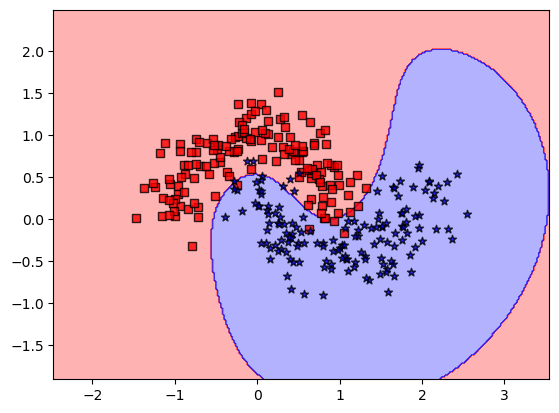

In [335]:
plot_decision_regions(X, y, rbf_svm)

# Come funziona sta roba?

sia $\phi$ la mappa tale che:
$$
x^{(i)} \in \mathbb R^d \to \phi(x^{(i)}) \in \mathbb R^{d'} \text { con } d' > d
$$

**problema**: calcolare questa mappa e trovare l'inverso e' costoso!

**soluzione**: posso modellare SVM come modello fatto di prodotti scalari $x^{(i)} \cdot x^{(j)}$.
* quando voglio passare alle $d'$ dimensioni allora e' possibile non dover calcolare la mappa $\phi$ su ogni vettore coinvolto nella moltiplicazione
* RBF: in questo modello posso calcolare il prodotto facilmente in $d'$ dimensioni avendo a disposizione $x$ in $d$ dimensioni!!!